# 01 — Datensammlung & Qualität

SPI-Extra-Universum laden, OHLCV und (Stichprobe) Fundamentaldaten über `src.data_loader` beziehen, Rohdaten inspizieren und Qualitätschecks sowie Visualisierungen ausführen.

**Hinweis:** Beim ersten Lauf lädt `download_ohlcv` alle Titel — das kann einige Minuten dauern. Zum Schnelltest `TICKER_LIMIT` unten setzen (z. B. `30`).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Project root (notebooks/ -> parent)
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src.data_loader import download_ohlcv, load_fundamentals
from src.universe import filter_by_min_volume, get_spi_extra_tickers

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)

## Universum & Download-Parameter

Konfiguration aus `config.py`: Zeitraum für yfinance, Mindestliquidität, optional Begrenzung der Tickeranzahl.

In [2]:
# None = alle SPI-Extra-Ticker; z. B. 25 für einen schnellen Smoke-Test
TICKER_LIMIT: int | None = None

all_tickers = get_spi_extra_tickers()
tickers = all_tickers if TICKER_LIMIT is None else all_tickers[:TICKER_LIMIT]

cache_dir = config.ensure_data_dir()
print(f"Projekt: {PROJECT_ROOT}")
print(f"Cache:   {cache_dir}")
print(f"Zeitraum OHLCV: {config.YF_START} … {config.YF_END}")
print(f"Ticker: {len(tickers)} von {len(all_tickers)} (SPI Extra)")

Projekt: /Users/stephangath/cursorAi/Stock Analysis AI
Cache:   /Users/stephangath/cursorAi/Stock Analysis AI/data
Zeitraum OHLCV: 2022-07-01 … 2025-12-31
Ticker: 194 von 194 (SPI Extra)


### OHLCV laden (`download_ohlcv`)

Parquet-Cache unter `data/ohlcv/`. Bereits vorhandene Dateien werden wiederverwendet, sofern kein erzwungener Refresh gesetzt ist.

In [3]:
FORCE_REFRESH = False  # True = alle Ticker neu von Yahoo laden

ohlcv_by_ticker = download_ohlcv(
    tickers,
    start=config.YF_START,
    end=config.YF_END,
    cache_dir=cache_dir,
    force_refresh=FORCE_REFRESH,
    max_workers=8,
    retries=2,
)

if not ohlcv_by_ticker:
    raise RuntimeError(
        "Keine OHLCV-Daten geladen — Verbindung/Ticker prüfen oder später erneut ausführen."
    )

loaded = set(ohlcv_by_ticker.keys())
requested = set(tickers)
failed = sorted(requested - loaded)
print(f"Erfolgreich geladen: {len(loaded)}")
print(f"Fehlend / übersprungen: {len(failed)}")
if failed[:10]:
    print("Beispiele:", failed[:10])

$ACHI.SW: possibly delisted; no timezone found

1 Failed download:
['ACHI.SW']: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AFP.SW"}}}
$AFP.SW: possibly delisted; no timezone found

1 Failed download:
['AFP.SW']: possibly delisted; no timezone found
$AIRE.SW: possibly delisted; no timezone found

1 Failed download:
['AIRE.SW']: possibly delisted; no timezone found
$ACHI.SW: possibly delisted; no timezone found

1 Failed download:
['ACHI.SW']: possibly delisted; no timezone found
$AFP.SW: possibly delisted; no timezone found

1 Failed download:
['AFP.SW']: possibly delisted; no timezone found
$ARON.SW: possibly delisted; no timezone found

1 Failed download:
['ARON.SW']: possibly delisted; no timezone found
$AIRE.SW: possibly delisted; no timezone found

1 Failed download:
['AIRE.SW']: possibly delisted; no timezone found
$ACHI.SW: possibly delisted; no timezone found

1 Failed

Erfolgreich geladen: 154
Fehlend / übersprungen: 40
Beispiele: ['ACHI.SW', 'AFP.SW', 'AIRE.SW', 'ARON.SW', 'BALN.SW', 'BLS.SW', 'BOBNN.SW', 'BPDG.SW', 'CIE.SW', 'CON.SW']


## Tabellarische Übersicht

Pro Ticker: Handelstage, Datumsbereich, fehlende Werte in Kernspalten.

In [4]:
CORE_COLS = ["Open", "High", "Low", "Close", "Volume"]


def summarize_ohlcv(ticker: str, df: pd.DataFrame) -> dict:
    idx = df.index
    row = {
        "ticker": ticker,
        "rows": len(df),
        "start": idx.min(),
        "end": idx.max(),
    }
    for c in CORE_COLS:
        if c in df.columns:
            row[f"pct_na_{c}"] = float(df[c].isna().mean())
        else:
            row[f"pct_na_{c}"] = np.nan
    return row


summary_rows = [summarize_ohlcv(t, df) for t, df in sorted(ohlcv_by_ticker.items())]
summary = pd.DataFrame(summary_rows)
summary.head(10)

,ticker,rows,start,end,pct_na_Open,pct_na_High,pct_na_Low,pct_na_Close,pct_na_Volume
0,ADEN.SW,879,2022-07-01,2025-12-30,0.0,0.0,0.0,0.0,0.0
1,ADVN.SW,879,2022-07-01,2025-12-30,0.0,0.0,0.0,0.0,0.0
2,ADXN.SW,879,2022-07-01,2025-12-30,0.0,0.0,0.0,0.0,0.0
3,AEVS.SW,879,2022-07-01,2025-12-30,0.0,0.0,0.0,0.0,0.0
4,ALLN.SW,879,2022-07-01,2025-12-30,0.0,0.0,0.0,0.0,0.0
5,ALSN.SW,879,2022-07-01,2025-12-30,0.0,0.0,0.0,0.0,0.0
6,AMS.SW,879,2022-07-01,2025-12-30,0.0,0.0,0.0,0.0,0.0
7,APGN.SW,879,2022-07-01,2025-12-30,0.0,0.0,0.0,0.0,0.0
8,ARBN.SW,879,2022-07-01,2025-12-30,0.0,0.0,0.0,0.0,0.0
9,ARYN.SW,879,2022-07-01,2025-12-30,0.0,0.0,0.0,0.0,0.0


In [5]:
# Aggregierte Kennzahlen über alle geladenen Serien
print("Handelstage (Rows): min / median / max")
print(summary["rows"].describe(percentiles=[0.5]).to_string())
na_cols = [c for c in summary.columns if c.startswith("pct_na_")]
if na_cols:
    print("\nFehlanteile (Median über Ticker) pro Spalte:")
    print(summary[na_cols].median().sort_values().to_string())

Handelstage (Rows): min / median / max
count    154.000000
mean     872.603896
std       60.809186
min      178.000000
50%      879.000000
max      879.000000

Fehlanteile (Median über Ticker) pro Spalte:
pct_na_Open      0.0
pct_na_High      0.0
pct_na_Low       0.0
pct_na_Close     0.0
pct_na_Volume    0.0


## Qualitätschecks

- Liquiditätsfilter (`filter_by_min_volume`) gemäß `config.MIN_DAILY_VOLUME_CHF`
- Stichprobe: Duplikate im Index, monotone Zeitachse

In [6]:
liquid_tickers = filter_by_min_volume(
    ohlcv_by_ticker,
    config.MIN_DAILY_VOLUME_CHF,
)
print(
    f"Über Mindestliquidität ({config.MIN_DAILY_VOLUME_CHF:,.0f} CHF Ø-Tagesumsatz): "
    f"{len(liquid_tickers)} / {len(ohlcv_by_ticker)}"
)

dup_index = []
non_monotonic = []
for t, df in ohlcv_by_ticker.items():
    if df.index.duplicated().any():
        dup_index.append(t)
    if not df.index.is_monotonic_increasing:
        non_monotonic.append(t)
print(f"Ticker mit Duplikaten im Index: {len(dup_index)}", dup_index[:5] if dup_index else "")
print(f"Ticker mit nicht-monotoner Zeitachse: {len(non_monotonic)}", non_monotonic[:5] if non_monotonic else "")

Über Mindestliquidität (50,000 CHF Ø-Tagesumsatz): 136 / 154
Ticker mit Duplikaten im Index: 0 
Ticker mit nicht-monotoner Zeitachse: 0 


### Fundamentaldaten (Stichprobe)

`load_fundamentals` nutzt JSON-Cache unter `data/fundamentals/`.

In [7]:
sample_ticker = liquid_tickers[0] if liquid_tickers else next(iter(ohlcv_by_ticker))
info = load_fundamentals(sample_ticker, cache_dir=cache_dir)
keys_of_interest = [
    "shortName",
    "sector",
    "marketCap",
    "trailingPE",
    "priceToBook",
    "dividendYield",
]
present = {k: info.get(k) for k in keys_of_interest if k in info}
pd.Series(present, name=sample_ticker)

shortName           ADECCO N
sector           Industrials
marketCap         3120755968
trailingPE          11.60625
priceToBook         1.005351
dividendYield           5.39
Name: ADEN.SW, dtype: object

## Visualisierung

Ladeerfolg, Verteilung der Handelstage, Kursverläufe (Auswahl), Verteilung des durchschnittlichen Tagesumsatzes.

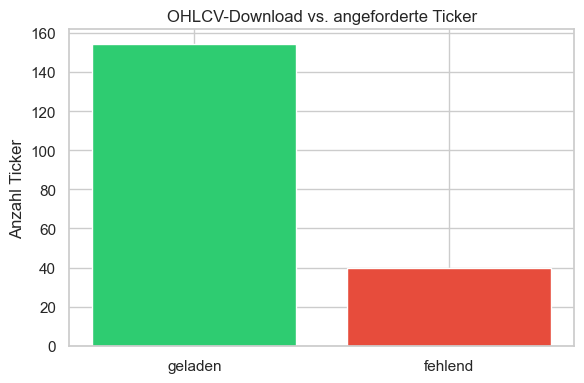

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    ["geladen", "fehlend"],
    [len(loaded), len(failed)],
    color=["#2ecc71", "#e74c3c"],
)
ax.set_ylabel("Anzahl Ticker")
ax.set_title("OHLCV-Download vs. angeforderte Ticker")
plt.tight_layout()
plt.show()

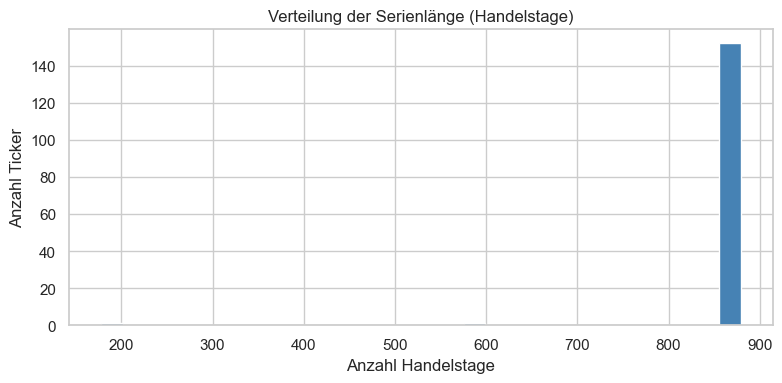

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(summary["rows"], bins=30, color="steelblue", edgecolor="white")
ax.set_xlabel("Anzahl Handelstage")
ax.set_ylabel("Anzahl Ticker")
ax.set_title("Verteilung der Serienlänge (Handelstage)")
plt.tight_layout()
plt.show()

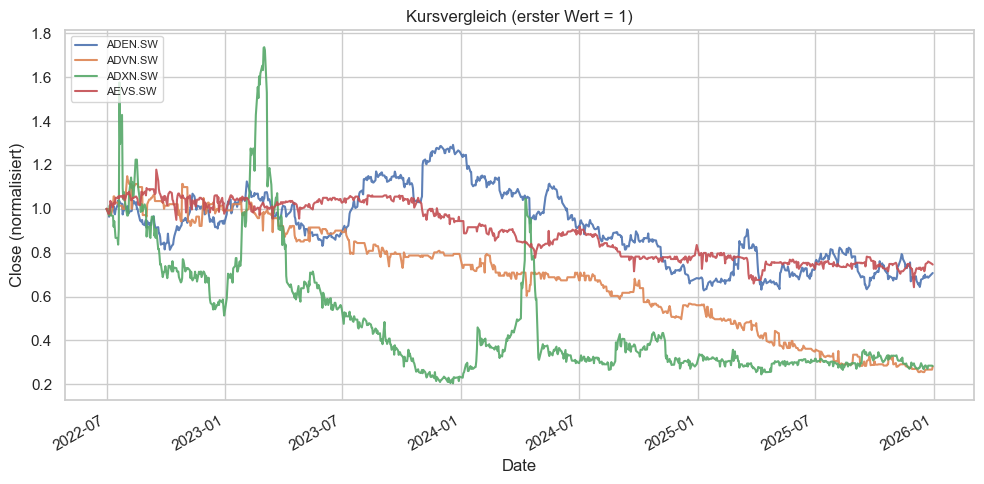

In [10]:
# Kursverläufe (normalisiert auf Start = 1) für eine kleine Auswahl
pick = sorted(loaded)[:4]
fig, ax = plt.subplots(figsize=(10, 5))
for t in pick:
    s = ohlcv_by_ticker[t]["Close"].dropna().astype(float)
    if s.empty:
        continue
    norm = s / s.iloc[0]
    norm.plot(ax=ax, label=t, alpha=0.9)
ax.set_ylabel("Close (normalisiert)")
ax.set_title("Kursvergleich (erster Wert = 1)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

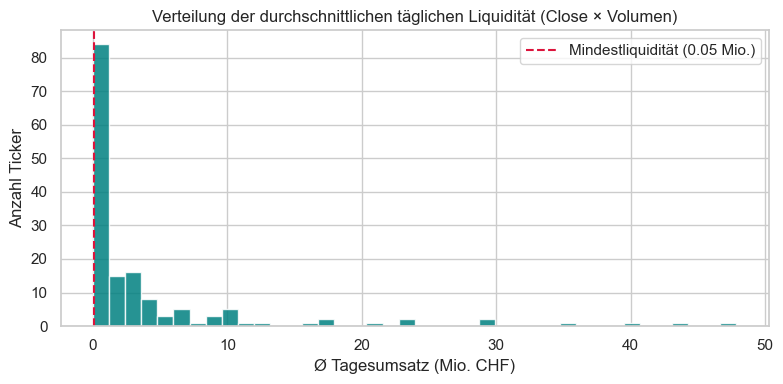

In [11]:
def mean_daily_turnover_chf(df: pd.DataFrame) -> float:
    p = pd.to_numeric(df["Close"], errors="coerce")
    v = pd.to_numeric(df["Volume"], errors="coerce")
    t = (p * v).dropna()
    return float(t.mean()) if not t.empty else float("nan")


turnovers = {t: mean_daily_turnover_chf(df) for t, df in ohlcv_by_ticker.items()}
turn_s = pd.Series(turnovers, name="mean_daily_turnover_chf").dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    turn_s.values / 1e6,
    bins=40,
    color="teal",
    edgecolor="white",
    alpha=0.85,
)
ax.axvline(
    config.MIN_DAILY_VOLUME_CHF / 1e6,
    color="crimson",
    linestyle="--",
    label=f"Mindestliquidität ({config.MIN_DAILY_VOLUME_CHF/1e6:.2f} Mio.)",
)
ax.set_xlabel("Ø Tagesumsatz (Mio. CHF)")
ax.set_ylabel("Anzahl Ticker")
ax.set_title("Verteilung der durchschnittlichen täglichen Liquidität (Close × Volumen)")
ax.legend()
plt.tight_layout()
plt.show()